# Pré-entraînement de la Value Head

Ce notebook pré-entraîne **uniquement la value head** du réseau, en gardant le tronc et la policy head gelés.

## Pourquoi ?
La value head n'a jamais été entraînée (gelée pendant l'entraînement supervisé).
En PPO, elle sert à calculer les **avantages GAE** : si ses estimations sont aléatoires, les gradients policy sont du bruit pur et dégradent la policy déjà entraînée.

## Comment ?
- On joue des parties avec la policy entraînée (mode PPO pour la collecte)
- On utilise `lam=1.0` et `gamma=1.0` → les **returns** = outcome final ±1 (sans bootstrap sur V(s))
- On entraîne la value head à prédire cet outcome : `MSE(V(s), returns)`
- Trunk + policy head sont gelés pendant tout l'entraînement

In [ ]:
import sys
sys.path.append('../onitama/')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
from tqdm import tqdm

from dl_players_v9 import DensePlayer_v9
from game import Game
from players import LookAheadHeuristicPlayer, HeuristicPlayer
from ppo import PPOBuffer

%matplotlib inline

2026-03-30 19:45:07.970611: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 19:45:07.970966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 19:45:08.017006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 19:45:08.969470: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

## Configuration

In [2]:
PRETRAINED_WEIGHTS = '../saved-models/Shigemori1.weights.h5'
SAVE_PATH         = '../saved-models/Shigemori2-value-head-pretrain'

N_ITERATIONS  = 100   # Nombre d'itérations collect + update
N_GAMES       = 128    # Parties par itération
N_EPOCHS      = 4     # Passes sur les données collectées
MINIBATCH_SIZE = 64
LEARNING_RATE = 3e-4  
# lam=1.0 + gamma=1.0 : returns = outcome final pur (±1), sans bootstrap sur V(s)
GAMMA = 1.0
LAM   = 1.0

SAVE_EVERY = 20
PLOT_EVERY = 1

## Initialisation du modèle

- Trunk (tronc CNN résiduel) → **gelé**
- Policy head → **gelée**
- Value head → **entraînable**

In [3]:
p1 = DensePlayer_v9()
#p1.load_weights(PRETRAINED_WEIGHTS)
p1.load_weights(PRETRAINED_WEIGHTS, skip_mismatch=True)

# Juste après load_weights, vérifier que les poids ne sont PAS aléatoires
p_random = DensePlayer_v9()

for layer in p1.model.layers:
    if 'trunk' in layer.name or 'policy' in layer.name:
        weights = layer.get_weights()
        weights_rnd = p_random.model.get_layer(layer.name).get_weights()
        if weights:
            loaded = not np.allclose(weights[0], weights_rnd[0])
            print(f"{layer.name}: {'✓ chargé' if loaded else '✗ RANDOM — non chargé !'}")


# Geler tronc + policy head (100% gelés, l'adaptateur value apprend à leur place)
p1.freeze_trunk()
for layer in p1.policy_layers:
    layer.trainable = False

#Désactiver le dropout sur la tête de valeur
p1.model.get_layer('value_dropout').rate = 0.0

# Vérification
total     = len(p1.model.layers)
trainable = sum(1 for l in p1.model.layers if l.trainable)
frozen    = total - trainable

print(f"Layers total     : {total}")
print(f"Layers gelés     : {frozen}  (trunk + policy)")
print(f"Layers actifs    : {trainable}  (value head dont value_adapter)")
print()
print(f"Variables entraînables : {len(p1.model.trainable_variables)}")
print()
print("Layers entraînables :")
for l in p1.model.layers:
    if l.trainable and l.get_weights():
        print(f"  {l.name}")

optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)

p2_opponent = [
    LookAheadHeuristicPlayer(heuristic_function="heuristic_defensive", max_depth=1),
    HeuristicPlayer(heuristic_function="heuristic_defensive")
]

print("\nModèle prêt.")

2026-03-30 19:45:27.553594: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


trunk_dense_0: ✓ chargé
trunk_ln_0: ✓ chargé
trunk_dense_1: ✓ chargé
trunk_ln_1: ✓ chargé
trunk_dense_2: ✓ chargé
trunk_ln_2: ✓ chargé
policy_hidden: ✓ chargé
policy_logits: ✓ chargé
Gelé 14 layers du tronc
Layers total     : 21
Layers gelés     : 17  (trunk + policy)
Layers actifs    : 4  (value head dont value_adapter)

Variables entraînables : 6

Layers entraînables :
  value_dense1
  value_dense2
  value_output

Modèle prêt.


In [4]:
# Test hors PPO : jouer 20 parties et vérifier les résultats réels
p1.setPPOTraining(False)
wins, losses, draws = 0, 0, 0
for _ in range(20):
    opp = np.random.choice(p2_opponent)
    game = Game(player_one=p1, player_two=opp, verbose=False)
    result = game.playGame(return_winner=True)
    if result == 1: wins += 1
    elif result == 2: losses += 1
    else: draws += 1
print(f"Wins: {wins}/20 | Losses: {losses}/20 | Draws (timeout): {draws}/20")


Wins: 14/20 | Losses: 6/20 | Draws (timeout): 0/20


## Fonctions de collecte et d'entraînement

In [5]:
def collect(player, opponent, n_games, gamma, lam):
    """
    Joue n_games parties et remplit un PPOBuffer.
    lam=1.0 + gamma=1.0 → returns[t] = outcome final (±1) pour chaque pas,
    sans dépendance aux estimations V(s) actuelles.
    opponent peut être un joueur unique ou une liste de joueurs (tirage aléatoire uniforme par partie).
    """
    player.setPPOTraining(True)

    buffer = PPOBuffer(p1=player, p2=opponent[0] if isinstance(opponent, list) else opponent, gamma=gamma, lam=lam)
    wins = losses = 0

    for _ in tqdm(range(n_games), desc="collect"):
        opp = np.random.choice(opponent) if isinstance(opponent, list) else opponent
        game = Game(player_one=player, player_two=opp, verbose=False, trainer=buffer)
        result = game.playGame(return_winner=True)
        if result == 1:
            wins += 1
        elif result == 2:
            losses += 1

    player.setPPOTraining(False)
    data = buffer.get()
    return data, wins, losses


def update_value_head(player, data, n_epochs, minibatch_size, optimizer):
    """
    Entraîne uniquement la value head.
    Loss : MSE(V(s), returns)  — returns = outcome final ±1
    """
    n = len(data['states'])
    value_losses = []

    for _ in range(n_epochs):
        indices = np.random.permutation(n)
        for start in range(0, n, minibatch_size):
            batch_idx = indices[start:start + minibatch_size]
            states  = tf.constant(data['states'][batch_idx])
            returns = tf.constant(data['returns'][batch_idx])

            with tf.GradientTape() as tape:
                _, values = player.model(states, training=True)
                values = tf.squeeze(values, axis=-1)
                value_loss = tf.reduce_mean(tf.square(values - returns))

            # model.trainable_variables = value head seulement (trunk + policy gelés)
            grads = tape.gradient(value_loss, player.model.trainable_variables)
            grads, _ = tf.clip_by_global_norm(grads, 1.0)
            optimizer.apply_gradients(zip(grads, player.model.trainable_variables))
            value_losses.append(float(value_loss))

    return np.mean(value_losses)


def compute_mse_by_position(player, data):
    """
    Calcule la MSE séparément pour les états en début et fin de trajectoire.

    Avec gamma=lam=1, tous les returns d'une même partie ont le même signe (±1).
    On identifie les trajectoires par blocs de returns consécutifs de même signe,
    puis on normalise la position de chaque transition dans sa trajectoire (0=début, 1=fin).

    Interprétation :
    - mse_late << mse_early → le modèle apprend bien les positions décisives,
      le plafond global est dû au bruit des états précoces (normal, acceptable).
    - mse_late ≈ mse_early ≈ 0.8 → plafond architectural : le modèle n'apprend
      rien même en fin de partie.
    """
    returns = data['returns']
    states  = data['states']
    n = len(returns)

    # Positions normalisées dans la trajectoire (0=début, 1=fin)
    # Un changement de signe dans returns = frontière entre deux trajectoires
    positions = np.zeros(n, dtype=np.float32)
    traj_start = 0
    for i in range(1, n + 1):
        if i == n or np.sign(returns[i]) != np.sign(returns[traj_start]):
            length = i - traj_start
            positions[traj_start:i] = np.linspace(0, 1, length) if length > 1 else [0.5]
            traj_start = i

    # Prédictions V(s) sur tout le batch
    _, v_all = player.model(tf.constant(states, dtype=tf.float32), training=False)
    v_all = tf.squeeze(v_all).numpy()

    early_mask = positions < 0.33
    late_mask  = positions > 0.67

    mse_early = float(np.mean((v_all[early_mask] - returns[early_mask])**2)) if early_mask.any() else float('nan')
    mse_late  = float(np.mean((v_all[late_mask]  - returns[late_mask])**2))  if late_mask.any()  else float('nan')

    return mse_early, mse_late

## Boucle d'entraînement


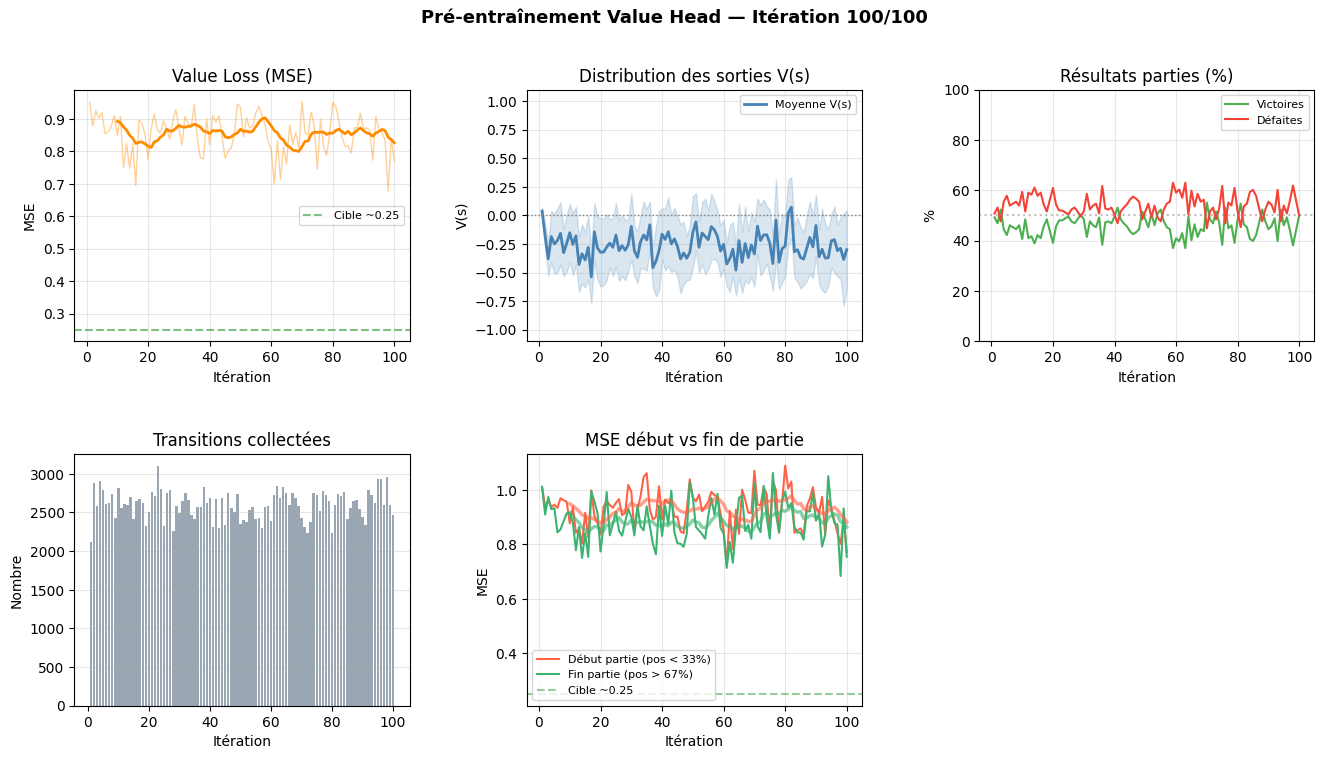

  → Sauvegardé : ../saved-models/Shigemori2-value-head-pretrain_iter100.weights.h5

Pré-entraînement value head terminé !


In [6]:
history = {
    'value_loss': [],
    'wins': [],
    'losses': [],
    'transitions': [],
    'value_mean': [],
    'value_std': [],
    'mse_early': [],
    'mse_late': [],
}

def plot(iteration):
    iters = list(range(1, iteration + 1))

    def moving_avg(values, w=10):
        if len(values) < w:
            return None, None
        kernel = np.ones(w) / w
        return list(range(w, len(values) + 1)), np.convolve(values, kernel, mode='valid')

    clear_output(wait=True)
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(f'Pré-entraînement Value Head — Itération {iteration}/{N_ITERATIONS}',
                 fontsize=13, fontweight='bold')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # Value loss
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(iters, history['value_loss'], color='darkorange', alpha=0.4, linewidth=1)
    xi, ys = moving_avg(history['value_loss'])
    if xi:
        ax1.plot(xi, ys, color='darkorange', linewidth=2)
    ax1.axhline(0.25, color='green', linestyle='--', alpha=0.5, label='Cible ~0.25')
    ax1.set_title('Value Loss (MSE)')
    ax1.set_xlabel('Itération')
    ax1.set_ylabel('MSE')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Distribution des sorties V(s)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(iters, history['value_mean'], color='steelblue', linewidth=2, label='Moyenne V(s)')
    v_mean = np.array(history['value_mean'])
    v_std  = np.array(history['value_std'])
    ax2.fill_between(iters, v_mean - v_std, v_mean + v_std, alpha=0.2, color='steelblue')
    ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax2.set_title('Distribution des sorties V(s)')
    ax2.set_xlabel('Itération')
    ax2.set_ylabel('V(s)')
    ax2.set_ylim(-1.1, 1.1)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Résultats parties
    ax3 = fig.add_subplot(gs[0, 2])
    wins   = np.array(history['wins'])
    losses = np.array(history['losses'])
    total  = wins + losses
    safe   = np.where(total == 0, 1, total)
    ax3.plot(iters, wins / safe * 100, color='#4caf50', linewidth=1.5, label='Victoires')
    ax3.plot(iters, losses / safe * 100, color='#f44336', linewidth=1.5, label='Défaites')
    ax3.axhline(50, color='gray', linestyle=':', alpha=0.5)
    ax3.set_title('Résultats parties (%)')
    ax3.set_xlabel('Itération')
    ax3.set_ylabel('%')
    ax3.set_ylim(0, 100)
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # Transitions collectées
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.bar(iters, history['transitions'], color='slategray', alpha=0.7, width=0.8)
    ax4.set_title('Transitions collectées')
    ax4.set_xlabel('Itération')
    ax4.set_ylabel('Nombre')
    ax4.grid(True, alpha=0.3, axis='y')

    # MSE début vs fin de trajectoire
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(iters, history['mse_early'], color='tomato',    linewidth=1.5, label='Début partie (pos < 33%)')
    ax5.plot(iters, history['mse_late'],  color='mediumseagreen', linewidth=1.5, label='Fin partie (pos > 67%)')
    xi_e, ys_e = moving_avg(history['mse_early'])
    xi_l, ys_l = moving_avg(history['mse_late'])
    if xi_e:
        ax5.plot(xi_e, ys_e, color='tomato',         linewidth=2.5, alpha=0.6)
        ax5.plot(xi_l, ys_l, color='mediumseagreen', linewidth=2.5, alpha=0.6)
    ax5.axhline(0.25, color='green', linestyle='--', alpha=0.4, label='Cible ~0.25')
    ax5.set_title('MSE début vs fin de partie')
    ax5.set_xlabel('Itération')
    ax5.set_ylabel('MSE')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3)

    plt.show()


for i in range(N_ITERATIONS):
    # 1. Collecte
    data, wins, losses = collect(p1, p2_opponent, N_GAMES, GAMMA, LAM)

    # 2. Stats sur les sorties V(s) du batch
    states_sample = tf.constant(data['states'][:256])
    _, v_sample = p1.model(states_sample, training=False)
    v_sample = v_sample.numpy().flatten()

    # 3. MSE début vs fin de trajectoire (avant update)
    mse_early, mse_late = compute_mse_by_position(p1, data)

    # 4. Mise à jour value head
    v_loss = update_value_head(p1, data, N_EPOCHS, MINIBATCH_SIZE, optimizer)

    # 5. Historique
    history['value_loss'].append(v_loss)
    history['wins'].append(wins)
    history['losses'].append(losses)
    history['transitions'].append(len(data['states']))
    history['value_mean'].append(float(np.mean(v_sample)))
    history['value_std'].append(float(np.std(v_sample)))
    history['mse_early'].append(mse_early)
    history['mse_late'].append(mse_late)

    print(f"[{i+1:4d}/{N_ITERATIONS}] "
          f"transitions={len(data['states'])} | "
          f"W/L={wins}/{losses} | "
          f"v_loss={v_loss:.4f} | "
          f"V(s) moy={np.mean(v_sample):.3f} ± {np.std(v_sample):.3f} | "
          f"MSE early={mse_early:.4f} late={mse_late:.4f}")

    if (i + 1) % PLOT_EVERY == 0:
        plot(i + 1)

    if SAVE_PATH and (i + 1) % SAVE_EVERY == 0:
        path = f"{SAVE_PATH}_iter{i+1}.weights.h5"
        p1.save_weights(path)
        print(f"  → Sauvegardé : {path}")

print("\nPré-entraînement value head terminé !")

## Vérification finale

On vérifie que la policy head n'a pas bougé (les poids du tronc et de la policy doivent être identiques aux poids chargés initialement).

In [8]:
# Charger un modèle de référence (poids originaux)
p_ref = DensePlayer_v9()
p_ref.load_weights(PRETRAINED_WEIGHTS)

# Comparer les poids de chaque partie du réseau
policy_unchanged  = True
trunk_0_3_unchanged = True  # blocs 0..3 doivent être gelés
res4_changed      = False   # res_block_4 doit avoir changé

for layer_trained, layer_ref in zip(p1.model.layers, p_ref.model.layers):
    if not layer_trained.get_weights():
        continue
    for w_trained, w_ref in zip(layer_trained.get_weights(), layer_ref.get_weights()):
        changed = not np.allclose(w_trained, w_ref)
        if 'policy' in layer_trained.name:
            if changed:
                policy_unchanged = False
        elif 'value' in layer_trained.name:
            pass  # attendu comme modifié
        elif 'res_block_4' in layer_trained.name:
            if changed:
                res4_changed = True
        else:
            if changed:
                trunk_0_3_unchanged = False

print(f"Tronc res_block_0..3 inchangé : {'✓' if trunk_0_3_unchanged else '✗ ATTENTION : des poids ont changé !'}")
print(f"Policy head inchangée         : {'✓' if policy_unchanged else '✗ ATTENTION : des poids ont changé !'}")
print(f"res_block_4 a évolué          : {'✓' if res4_changed else '✗ Pas de changement détecté (vérifier le gel)'}")
print()
print("Value loss finale (10 dernières itérations) :",
      f"{np.mean(history['value_loss'][-10:]):.4f}")
print()
print("Prochaine étape : lancer ppo_training.ipynb avec ces poids pour le fine-tuning PPO complet.")

Tronc res_block_0..3 inchangé : ✓
Policy head inchangée         : ✓
res_block_4 a évolué          : ✗ Pas de changement détecté (vérifier le gel)

Value loss finale (10 dernières itérations) : 0.8265

Prochaine étape : lancer ppo_training.ipynb avec ces poids pour le fine-tuning PPO complet.
